# $O(n \log n)$ distance-weighted bipartite matching on a real road network with pyrosm and GeoPandas

In this notebook we demonstrate the usage of an efficient $O(n \log n)$ algorithm to compute the optimal distance-weighted matching between two sets of points distributed over a [metric graph](https://en.wikipedia.org/wiki/Quantum_graph#Metric_graphs). Specifically, we use the driving network of Cambridge, MA. Note, the roadmap includes both one-way roads and those with bidirectional travel simultaneously, which our algorithms support.

## Introducing Cambridge, MA

We begin by loading data using the tutorial material on the PYROSM website.

Number of roads: 9914


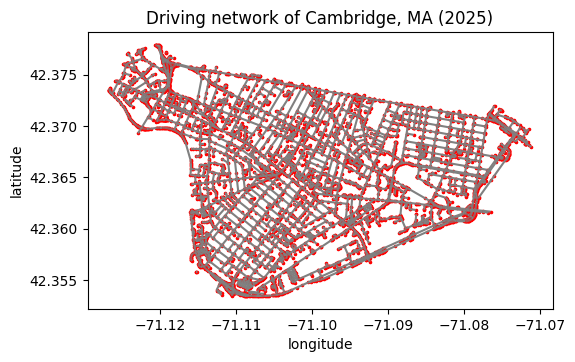

In [11]:
"""
Starting with the online tutorial.
https://pyrosm.readthedocs.io/en/stable/basics.html#

"""
from pyrosm import OSM
import matplotlib.pyplot as plt

# Data prepared using UI at https://extract.bbbike.org/
# https://pyrosm.readthedocs.io/en/stable/basics.html#protobuf-file-what-is-it-and-how-to-get-one
path = "data/cam.osm.pbf"
osm = OSM(path)

# Read nodes and edges of the 'driving' network
nodes, edges = osm.get_network(nodes=True, network_type="driving")

# Plot nodes and edges on a map
ax = edges.plot(figsize=(6,6), color="gray")
nodes.plot(color="red", markersize=2.5, ax=ax)
plt.title("Driving network of Cambridge, MA (2025)")
plt.xlabel("longitude")
plt.ylabel("latitude");

print(f"Number of roads: {len(edges)}")

For higher-fidelity distance calculations in meters, we will use a more appropriate map projection for the region of interest (the Boston area).

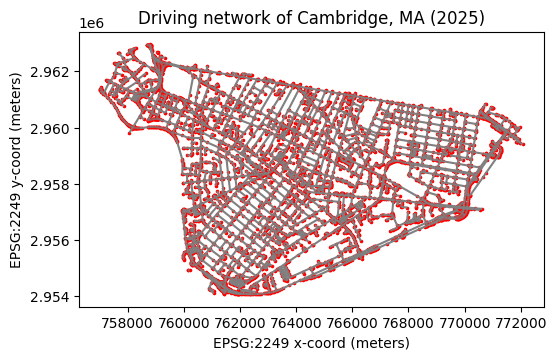

In [2]:
# Project to Boston area for metric (near-Euclidean) distance
nodes, edges = map(lambda gdf: gdf.to_crs("EPSG:2249"), (nodes, edges))

# Plot nodes and edges on a map
ax = edges.plot(figsize=(6,6), color="gray")
nodes.plot(color="red", markersize=2.5, ax=ax)
plt.title("Driving network of Cambridge, MA (2025)")
plt.xlabel("EPSG:2249 x-coord (meters)")
plt.ylabel("EPSG:2249 y-coord (meters)");

## Thesis statement

The gray segments show the space occupied by roads in Cambridge, and the red dots show the locations of interchange. While there are many red dots, of course they do not cover the whole continuum of the road network.

Typically, if you want to know the shortest path between two points on the network, the standard way is to find the nearest vertices to the query points, and use the graph shortest path (distance) as a proxy.
Indeed, the PYROSM docs have a tutorial for this method:
https://pyrosm.readthedocs.io/en/stable/graphs.html#calculate-shortest-paths

Our library provides support if you would like higher precision than that. To our library a point is the tuple $(r, x)$ of a road $r$ and a coordinate $x$ describing the distance one would travel along that road from its left endpoint to reach the point.

In [3]:
# Build a representation of the distance metric
from setiptah.roadgeometry.graphs import RoadNetwork

rn = RoadNetwork()
node_location = {}  # POINT geometries for network vertices
edge_shape = {}  # LineString geometries (oriented) for network edges

for _, row in nodes.iterrows():
    rn.add_node(row.id)
    pt = row.geometry
    node_location[row.id] = (pt.x, pt.y)

for r, row in edges.iterrows():
    rn.add_edge(r, row.u, row.v, row.geometry.length, oneway=row.oneway == "yes")
    edge_shape[r] = row.geometry

from collections import Counter
print("One way roads?")
Counter(rn.is_oneway(road) for road in rn.edges())

One way roads?


Counter({False: 5092, True: 4822})

## Matching / Assignment

We will demonstrate our shortest path capabilities within the context of another major contribution of the library: an algorithm to provide a minimum matching between supply and demand in the sense of least total shortest path distance on a network.

To demonstrate, suppose we have $n$ units of some commodity / supply (...probably pizza) loaded in trucks at various locations in the network. They need to be delivered to $n$ consumers / demand (grad students) at other locations.

### Naive Matching

We'll start by demonstrating how to compute the "carbon footprint" of a matching.

First, let's sample some points..

Sampling on the road network


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:04<00:00, 17.09it/s]


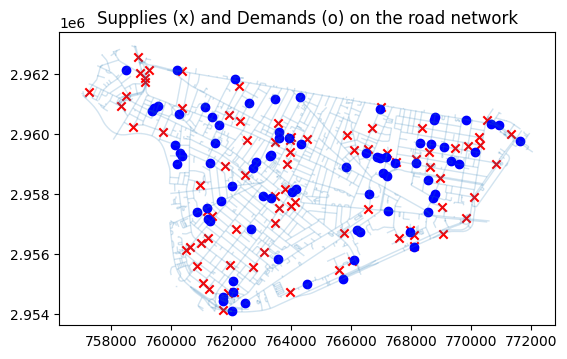

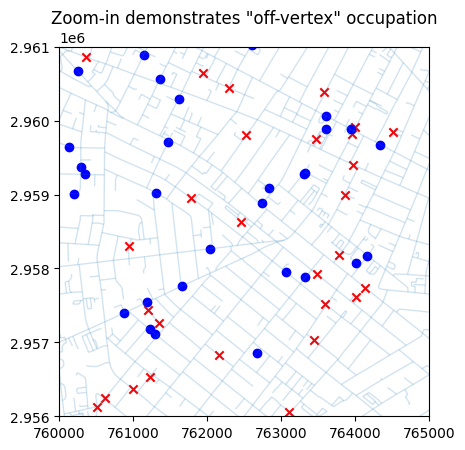

In [4]:
# Sample some supply and demand on the network continuum.

from setiptah.roadgeometry.formats import to_networkx
import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm import tqdm

roadmap = to_networkx(rn)

import setiptah.roadgeometry.probability as roadprob

uniform = roadprob.UniformDist(roadmap)


M = 80

print("Sampling on the road network")
from setiptah.roadgeometry.dijkstra import RoadnetMetric
metric = RoadnetMetric(rn)

supply, demand = [], []
for _ in tqdm(range(M)):
    while True:
        s, t = [tuple(uniform.sample()) for _ in range(2)]
        if metric.distance(s, t) < np.inf:
            supply.append(s)
            demand.append(t)
            break

def embed_point(p):
    # Interpolate the edge LineString to find the point on the map. 
    road, x = p
    return edge_shape[road].interpolate(x)

def wrap_geoms(shapes):
    """Simple shapes list -> GeoDF wrapper."""
    return gpd.GeoDataFrame({
        "shape": shapes
    }, geometry="shape", crs=edges.crs)

supply_gdf, demand_gdf = [
    wrap_geoms(map(embed_point, pts)) for pts in (supply, demand)
]

def draw(ax=None):
    ax = ax or plt.gca()
    ax = edges.plot(linewidth=1, alpha=.2, ax=ax)
    supply_gdf.plot(color="red", marker="x", ax=ax)
    demand_gdf.plot(color="blue", marker="o", ax=ax)
    return ax

draw()
plt.title("Supplies (x) and Demands (o) on the road network")
plt.figure()
# plt.subplot(1, 2, 2)
draw()
plt.title('Zoom-in demonstrates "off-vertex" occupation')
xc, yc = 762500, 2958500
w, h = 5000, 5000
plt.axis([xc - w / 2, xc + w / 2, yc - h / 2, yc + h / 2]);

Now suppose we naively match the first supply to first demand, the second to the second, and so on.
Let's calculate the total shortest path distance.

In [5]:
# Prepare some shortest path caching
from setiptah.roadgeometry.dijkstra import create_path_network, RoadnetMetric

def all_points():
    yield from supply
    yield from demand

pathnet = create_path_network(all_points(), rn)
path_metric = RoadnetMetric(pathnet)
trails = {}

In [6]:
# Record the "carbon footprint" of the matching.
# For each segment in the network, add up the number of shortest paths traversing the segment.
from setiptah.roadgeometry.dijkstra import create_path_network, RoadnetMetric, PointNode, get_segment
from setiptah.roadgeometry.util.shapely import crop_line_string

r = range(len(supply))
naive_matching = list(zip(r, r))


print("Calculating link weights")

def get_link_weights(matching):
    weights = {}

    for i, j in tqdm(matching):
        s, t = supply[i], demand[j]
        add_shortest_path(PointNode(s), PointNode(t), weights)

    return weights

def add_shortest_path(u, v, weights):
    path = path_metric.graph_shortest_path(u, v)
    for link in path[1::2]:

        if link not in weights:
            weights[link] = 0

        if link not in trails:
            seg = get_segment(*pathnet.endpoints(link), rn)

            road = seg.road
            start, end = sorted([seg.start, seg.end])

            trails[link] = crop_line_string(edge_shape[road], start, end)

        weights[link] += 1


naive_weights = get_link_weights(naive_matching)

Calculating link weights


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:03<00:00, 22.67it/s]


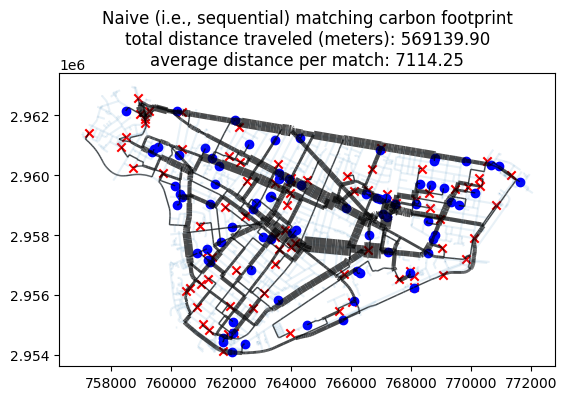

In [7]:
# Visualize the carbon footprint.
df = pd.Series(naive_weights, name="carbon").to_frame()
with_trails = gpd.GeoDataFrame(
    df.assign(trail=df.index.map(trails.__getitem__)),
    geometry="trail",
    crs=edges.crs,
)

ax = plt.gca()
ax = edges.plot(alpha=.1, ax=ax)
ax = with_trails.plot(linewidth=with_trails.carbon, alpha=.7, colors="black", ax=ax)
ax = supply_gdf.plot(color="red", marker="x", ax=ax)
ax = demand_gdf.plot(color="blue", marker="o", ax=ax);

total_distance = sum(
    num_paths_over_link * trails[link].length
    for link, num_paths_over_link in naive_weights.items()
)

plt.title("\n".join([
    "Naive (i.e., sequential) matching carbon footprint",
    f"total distance traveled (meters): {total_distance:.02f}",
    f"average distance per match: {total_distance / M:.02f}",
]));

An interesting feature of this plot is that it predicts where the heavy congestion areas are likely to be.

### Optimal Matching

Now let's find an optimal matching using the present library.

In [8]:
from setiptah.roadgeometry.matching import RoadnetMatchingProblem, MatchingResult

optimal_matching, optimal_cost = RoadnetMatchingProblem(supply, demand, rn).compute_optimal_results(MatchingResult.MATCHING, MatchingResult.COST)

In [9]:
# Calculate the carbon footprint.
optimal_weights = get_link_weights(optimal_matching)

total_distance_optimal = sum(
    num_paths_over_link * trails[link].length
    for link, num_paths_over_link in optimal_weights.items()
)
error = total_distance_optimal - optimal_cost
assert error < 1e-10

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:00<00:00, 4778.68it/s]


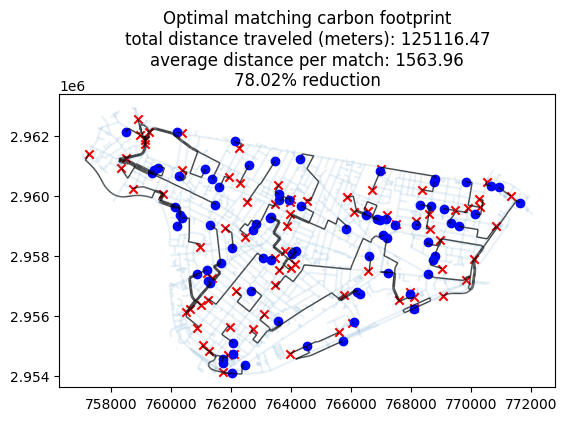

In [10]:
# Visual optimal matching.
df = pd.Series(optimal_weights, name="carbon").to_frame()
with_trails = gpd.GeoDataFrame(
    df.assign(trail=df.index.map(trails.__getitem__)),
    geometry="trail",
    crs=edges.crs,
)

ax = edges.plot(alpha=.1)
ax = with_trails.plot(linewidth=with_trails.carbon, alpha=.7, colors="black", ax=ax)
ax = supply_gdf.plot(color="red", marker="x", ax=ax)
ax = demand_gdf.plot(color="blue", marker="o", ax=ax);

reduction = (total_distance - total_distance_optimal) / total_distance
plt.title("\n".join([
    "Optimal matching carbon footprint",
    f"total distance traveled (meters): {total_distance_optimal:.02f}",
    f"average distance per match: {total_distance_optimal / M:.02f}",
    f"{reduction * 100:.02f}% reduction",
]));

The total cost reduction is of course significant.
And it becomes more and more significant as the instance size increases!

## Conclusion

- We have loaded a real world road network using PYROSM, and inspected it with GeoPandas.
- We have translated the network into a metric graph representation understood by the present framework.
- We briefly discussed the limitations of the standard way to obtain shortest path routing, which our library solves.
- We introduced the bipartite matching problem using a pizza delivery metaphor.
- Then, we demonstrated uniformly distributed random sampling over the road network to obtain a demo instance of supply and demand.
- We showed how to calculate and plot the "carbon footprint" (total distance traveled) of a naive matching solution.
- Next, we used our asymptotically efficient $O(n \log n)$ algorithm to compute an optimal matching in the sense of least total distance.
- Finally, we plotted the carbon footprint of the optimal solution, showing a significant reduction.